REAL INSTAGRAM ENGAGEMENT TARGET CONSTRUCTION

Current notebook directory:
d:\newwwwwwww\AiBasedInstagramPrediction\notebooks

Project root:
d:\newwwwwwww\AiBasedInstagramPrediction

Raw data directory:
d:\newwwwwwww\AiBasedInstagramPrediction\datasets\raw

Results directory:
d:\newwwwwwww\AiBasedInstagramPrediction\results\real_target

PATH VALIDATION

Project root exists: True
Datasets directory exists: True
Raw directory exists: True

CSV FILE DISCOVERY

CSV files found: 6
01. d:\newwwwwwww\AiBasedInstagramPrediction\datasets\raw\Instagram - Posts.csv
02. d:\newwwwwwww\AiBasedInstagramPrediction\datasets\raw\Instagram - Posts2.csv
03. d:\newwwwwwww\AiBasedInstagramPrediction\datasets\raw\instagram_analytics.csv
04. d:\newwwwwwww\AiBasedInstagramPrediction\datasets\raw\instagram_data\captions_csv.csv
05. d:\newwwwwwww\AiBasedInstagramPrediction\datasets\raw\instagram_data2\captions_csv2.csv
06. d:\newwwwwwww\AiBasedInstagramPrediction\datasets\raw\instagram_reach.csv

LOADING DATASET

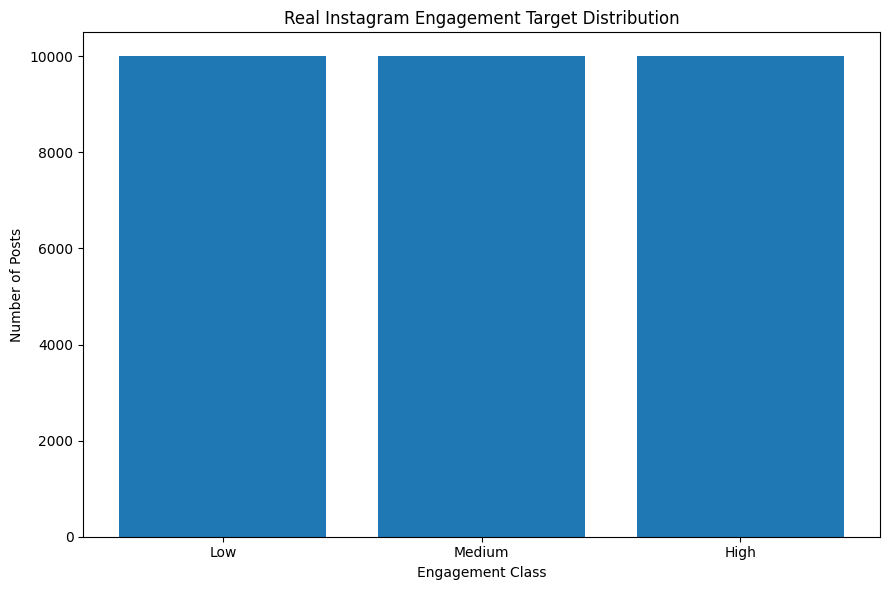

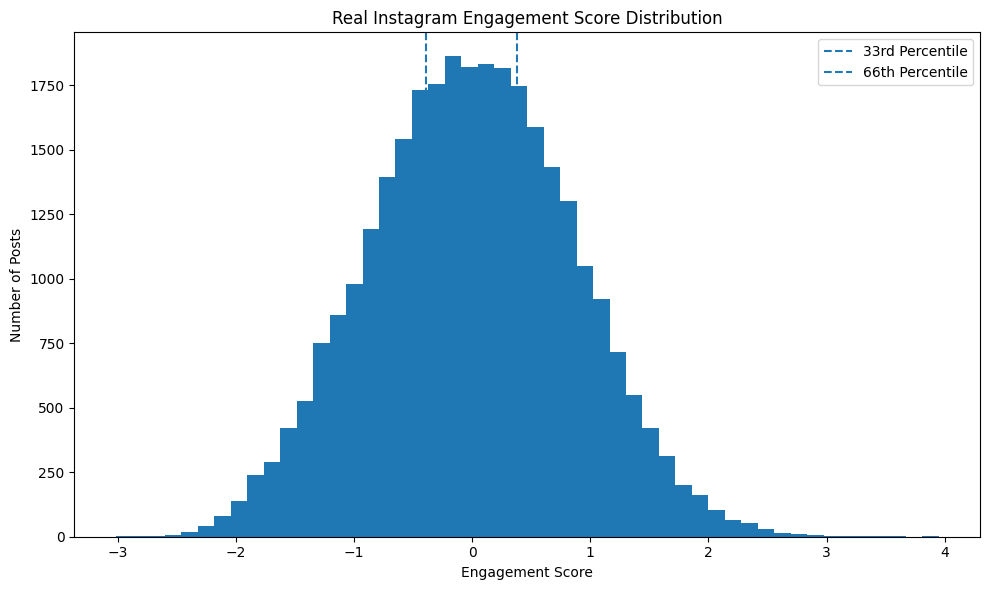


BUILDING REAL TARGET DATASET

Target dataset saved:
d:\newwwwwwww\AiBasedInstagramPrediction\results\real_target\real_instagram_engagement_target.csv

FINAL TARGET VALIDATION

Records: 29,999

Target column:
performance_class

Missing target: 0
Missing engagement score: 0

Target classes:
  Low     :   10,000 ( 33.33%)
  Medium  :    9,999 ( 33.33%)
  High    :   10,000 ( 33.33%)

REAL ENGAGEMENT TARGET CONSTRUCTION COMPLETED

Main output:
d:\newwwwwwww\AiBasedInstagramPrediction\results\real_target\real_instagram_engagement_target.csv

Results directory:
d:\newwwwwwww\AiBasedInstagramPrediction\results\real_target

NEXT STEP:
REAL MULTIMODAL DATASET CONSTRUCTION


In [3]:
# ============================================================
# 19 - REAL INSTAGRAM ENGAGEMENT TARGET CONSTRUCTION
# ROBUST PATH VERSION
# ============================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


# ============================================================
# 1. AUTOMATIC PROJECT PATH DISCOVERY
# ============================================================

print("=" * 70)
print("REAL INSTAGRAM ENGAGEMENT TARGET CONSTRUCTION")
print("=" * 70)

CURRENT_DIR = Path.cwd()

print("\nCurrent notebook directory:")
print(CURRENT_DIR)


def find_project_root(start_path):

    candidates = [
        start_path,
        *start_path.parents
    ]

    for candidate in candidates:

        if (
            (candidate / "datasets").exists()
            and
            (candidate / "models").exists()
        ):
            return candidate

        if (
            (candidate / "datasets").exists()
            and
            (candidate / "notebooks").exists()
        ):
            return candidate

    return None


PROJECT_ROOT = find_project_root(
    CURRENT_DIR
)


# ============================================================
# 2. FALLBACK SEARCH
# ============================================================

if PROJECT_ROOT is None:

    print(
        "\nProject root was not found from notebook directory."
    )

    print(
        "\nSearching current directory tree..."
    )

    matches = []

    for p in CURRENT_DIR.rglob("datasets"):

        if p.is_dir():

            parent = p.parent

            if (
                (parent / "notebooks").exists()
                or
                (parent / "models").exists()
            ):

                matches.append(parent)

    if matches:

        PROJECT_ROOT = matches[0]


if PROJECT_ROOT is None:

    raise FileNotFoundError(
        """
Could not automatically locate the project root.

Please make sure this notebook is inside:
AiBasedInstagramPrediction/notebooks/
"""
    )


RAW_DIR = (
    PROJECT_ROOT /
    "datasets" /
    "raw"
)

RESULTS_DIR = (
    PROJECT_ROOT /
    "results" /
    "real_target"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("\nProject root:")
print(PROJECT_ROOT)

print("\nRaw data directory:")
print(RAW_DIR)

print("\nResults directory:")
print(RESULTS_DIR)


# ============================================================
# 3. VALIDATE PATHS
# ============================================================

print("\n" + "=" * 70)
print("PATH VALIDATION")
print("=" * 70)

print(
    "\nProject root exists:",
    PROJECT_ROOT.exists()
)

print(
    "Datasets directory exists:",
    (PROJECT_ROOT / "datasets").exists()
)

print(
    "Raw directory exists:",
    RAW_DIR.exists()
)

if not RAW_DIR.exists():

    print("\nAvailable directories:")

    for p in PROJECT_ROOT.rglob("*"):

        if p.is_dir():

            print(p)

    raise FileNotFoundError(
        f"\nRaw dataset directory was not found:\n{RAW_DIR}"
    )


# ============================================================
# 4. DISCOVER ALL CSV FILES
# ============================================================

print("\n" + "=" * 70)
print("CSV FILE DISCOVERY")
print("=" * 70)

csv_files = sorted(
    RAW_DIR.rglob("*.csv")
)

print(
    f"\nCSV files found: {len(csv_files)}"
)

if not csv_files:

    raise FileNotFoundError(
        f"No CSV files found inside:\n{RAW_DIR}"
    )


for i, path in enumerate(
    csv_files,
    1
):

    print(
        f"{i:02d}. {path}"
    )


# ============================================================
# 5. LOAD DATASETS
# ============================================================

print("\n" + "=" * 70)
print("LOADING DATASETS")
print("=" * 70)

datasets = {}

for path in csv_files:

    try:

        data = pd.read_csv(
            path,
            low_memory=False
        )

        datasets[path] = data

        print(
            f"\n✓ {path.name}"
        )

        print(
            f"  Rows    : {len(data):,}"
        )

        print(
            f"  Columns : {len(data.columns)}"
        )

    except Exception as e:

        print(
            f"\n✗ {path.name}"
        )

        print(
            f"  Error: {e}"
        )


# ============================================================
# 6. COLUMN NORMALIZATION
# ============================================================

def normalize_column_name(name):

    return (
        str(name)
        .strip()
        .lower()
        .replace("\ufeff", "")
        .replace(" ", "_")
        .replace("-", "_")
    )


# ============================================================
# 7. ENGAGEMENT FIELD DEFINITIONS
# ============================================================

ENGAGEMENT_ALIASES = {

    "likes": [
        "likes",
        "like_count",
        "likes_count",
        "num_likes"
    ],

    "comments": [
        "comments",
        "comment_count",
        "comments_count",
        "num_comments"
    ],

    "shares": [
        "shares",
        "share_count",
        "shares_count",
        "num_shares"
    ],

    "saves": [
        "saves",
        "save_count",
        "saves_count",
        "num_saves"
    ],

    "reach": [
        "reach",
        "accounts_reached",
        "reached"
    ],

    "impressions": [
        "impressions",
        "impression_count"
    ],

    "engagement_rate": [
        "engagement_rate",
        "engagementrate",
        "engagement"
    ]
}


def find_matching_column(
    dataframe,
    aliases
):

    normalized_columns = {
        normalize_column_name(c): c
        for c in dataframe.columns
    }

    for alias in aliases:

        normalized_alias = (
            normalize_column_name(alias)
        )

        if normalized_alias in normalized_columns:

            return normalized_columns[
                normalized_alias
            ]

    return None


# ============================================================
# 8. DISCOVER ENGAGEMENT FIELDS
# ============================================================

print("\n" + "=" * 70)
print("ENGAGEMENT FIELD DISCOVERY")
print("=" * 70)

candidate_tables = []

for path, dataframe in datasets.items():

    found_fields = {}

    for logical_name, aliases in (
        ENGAGEMENT_ALIASES.items()
    ):

        actual_column = find_matching_column(
            dataframe,
            aliases
        )

        if actual_column is not None:

            found_fields[
                logical_name
            ] = actual_column

    print("\n" + "-" * 70)

    print(
        f"FILE: {path.name}"
    )

    if found_fields:

        print(
            "\nEngagement fields found:"
        )

        for logical, actual in (
            found_fields.items()
        ):

            print(
                f"  ✓ {logical:<20} -> {actual}"
            )

    else:

        print(
            "\nNo engagement fields found."
        )

    interaction_fields_found = sum(
        field in found_fields
        for field in [
            "likes",
            "comments",
            "shares",
            "saves"
        ]
    )

    # At least two interaction measures
    if interaction_fields_found >= 2:

        candidate_tables.append(
            (
                path,
                dataframe,
                found_fields,
                interaction_fields_found
            )
        )


# ============================================================
# 9. SELECT BEST DATASET
# ============================================================

if not candidate_tables:

    print("\n" + "=" * 70)
    print("NO SUITABLE ENGAGEMENT DATASET")
    print("=" * 70)

    print(
        "\nAvailable columns:"
    )

    for path, dataframe in datasets.items():

        print(
            f"\n{path.name}:"
        )

        print(
            list(dataframe.columns)
        )

    raise ValueError(
        "\nNo dataset with sufficient engagement "
        "interaction fields was found."
    )


candidate_tables.sort(
    key=lambda x: x[3],
    reverse=True
)

selected_path = candidate_tables[0][0]
df = candidate_tables[0][1].copy()
field_map = candidate_tables[0][2]


print("\n" + "=" * 70)
print("SELECTED REAL ENGAGEMENT DATASET")
print("=" * 70)

print(
    f"\nFile:"
)

print(
    selected_path
)

print(
    f"\nRows: {len(df):,}"
)

print(
    "\nSelected engagement fields:"
)

for logical, actual in field_map.items():

    print(
        f"  ✓ {logical:<20} -> {actual}"
    )


# ============================================================
# 10. CREATE STANDARDIZED COLUMN NAMES
# ============================================================

for logical_name, actual_name in (
    field_map.items()
):

    if actual_name != logical_name:

        df[
            logical_name
        ] = df[
            actual_name
        ]


# ============================================================
# 11. NUMERIC CONVERSION
# ============================================================

interaction_fields = [
    field
    for field in [
        "likes",
        "comments",
        "shares",
        "saves"
    ]
    if field in df.columns
]

post_publication_fields = [
    field
    for field in [
        "reach",
        "impressions",
        "engagement_rate"
    ]
    if field in df.columns
]


print("\n" + "=" * 70)
print("NUMERIC FIELD PREPARATION")
print("=" * 70)

print(
    "\nInteraction fields:"
)

for field in interaction_fields:

    print(
        f"  ✓ {field}"
    )


print(
    "\nPost-publication fields:"
)

for field in post_publication_fields:

    print(
        f"  ✓ {field}"
    )


for field in (
    interaction_fields +
    post_publication_fields
):

    df[field] = pd.to_numeric(
        df[field],
        errors="coerce"
    )


# ============================================================
# 12. DATA QUALITY
# ============================================================

print("\n" + "=" * 70)
print("ENGAGEMENT DATA QUALITY")
print("=" * 70)

quality_rows = []

for field in (
    interaction_fields +
    post_publication_fields
):

    series = df[field]

    quality_rows.append({

        "Feature": field,

        "Missing_Count":
            int(series.isna().sum()),

        "Missing_Percentage":
            round(
                series.isna().mean() * 100,
                3
            ),

        "Zero_Count":
            int((series == 0).sum()),

        "Unique_Values":
            int(series.nunique()),

        "Mean":
            float(series.mean()),

        "Median":
            float(series.median()),

        "Minimum":
            float(series.min()),

        "Maximum":
            float(series.max())
    })


quality_df = pd.DataFrame(
    quality_rows
)

print(
    quality_df.to_string(
        index=False
    )
)


quality_df.to_csv(
    RESULTS_DIR /
    "real_engagement_field_quality.csv",
    index=False
)


# ============================================================
# 13. CREATE ENGAGEMENT SCORE
# ============================================================

print("\n" + "=" * 70)
print("CREATING REAL ENGAGEMENT SCORE")
print("=" * 70)


interaction_data = (
    df[
        interaction_fields
    ]
    .copy()
    .fillna(0)
    .clip(lower=0)
)


# Log transformation
log_data = np.log1p(
    interaction_data
)


# Standardize each interaction feature
component_scores = pd.DataFrame(
    index=df.index
)


for field in interaction_fields:

    values = log_data[field]

    mean_value = values.mean()

    std_value = values.std()

    if (
        std_value == 0
        or
        pd.isna(std_value)
    ):

        component_scores[
            field
        ] = 0.0

    else:

        component_scores[
            field
        ] = (
            values -
            mean_value
        ) / std_value


df[
    "real_engagement_score"
] = component_scores.mean(
    axis=1
)


print(
    f"\nMean   : "
    f"{df['real_engagement_score'].mean():.6f}"
)

print(
    f"Std    : "
    f"{df['real_engagement_score'].std():.6f}"
)

print(
    f"Minimum: "
    f"{df['real_engagement_score'].min():.6f}"
)

print(
    f"Maximum: "
    f"{df['real_engagement_score'].max():.6f}"
)


# ============================================================
# 14. QUANTILE TARGET CREATION
# ============================================================

q33 = df[
    "real_engagement_score"
].quantile(
    1 / 3
)

q66 = df[
    "real_engagement_score"
].quantile(
    2 / 3
)


print("\nTarget thresholds:")

print(
    f"33rd percentile: {q33:.6f}"
)

print(
    f"66th percentile: {q66:.6f}"
)


def classify_engagement(score):

    if score <= q33:

        return "Low"

    elif score <= q66:

        return "Medium"

    return "High"


df[
    "performance_class"
] = (
    df[
        "real_engagement_score"
    ]
    .apply(
        classify_engagement
    )
)


# ============================================================
# 15. TARGET DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("REAL TARGET DISTRIBUTION")
print("=" * 70)


distribution = (
    df[
        "performance_class"
    ]
    .value_counts()
    .reindex(
        [
            "Low",
            "Medium",
            "High"
        ]
    )
    .fillna(0)
    .astype(int)
)


distribution_df = pd.DataFrame({

    "Class":
        distribution.index,

    "Count":
        distribution.values,

    "Percentage":
        (
            distribution.values /
            len(df) *
            100
        )
})


print(
    distribution_df.to_string(
        index=False
    )
)


distribution_df.to_csv(
    RESULTS_DIR /
    "real_target_distribution.csv",
    index=False
)


# ============================================================
# 16. CLASS ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("CLASS-WISE ENGAGEMENT ANALYSIS")
print("=" * 70)


class_columns = (
    interaction_fields +
    [
        "real_engagement_score"
    ]
)


class_analysis = (
    df
    .groupby(
        "performance_class"
    )[
        class_columns
    ]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std"
        ]
    )
)


print(
    class_analysis
)


class_analysis.to_csv(
    RESULTS_DIR /
    "real_target_class_statistics.csv"
)


# ============================================================
# 17. TARGET DISTRIBUTION PLOT
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.bar(
    distribution.index,
    distribution.values
)

plt.title(
    "Real Instagram Engagement Target Distribution"
)

plt.xlabel(
    "Engagement Class"
)

plt.ylabel(
    "Number of Posts"
)

plt.tight_layout()


plt.savefig(
    RESULTS_DIR /
    "real_engagement_target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 18. SCORE DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    df[
        "real_engagement_score"
    ],
    bins=50
)

plt.axvline(
    q33,
    linestyle="--",
    label="33rd Percentile"
)

plt.axvline(
    q66,
    linestyle="--",
    label="66th Percentile"
)

plt.title(
    "Real Instagram Engagement Score Distribution"
)

plt.xlabel(
    "Engagement Score"
)

plt.ylabel(
    "Number of Posts"
)

plt.legend()

plt.tight_layout()


plt.savefig(
    RESULTS_DIR /
    "real_engagement_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 19. BUILD REAL TARGET DATASET
# ============================================================

print("\n" + "=" * 70)
print("BUILDING REAL TARGET DATASET")
print("=" * 70)


output_columns = []


# Identifiers
identifier_candidates = [

    "post_id",
    "account_id",
    "url",
    "user_posted",
    "post_datetime",
    "post_date",
    "image_file"
]


for field in identifier_candidates:

    if field in df.columns:

        output_columns.append(
            field
        )


# Content
content_candidates = [

    "description",
    "caption",
    "hashtags",
    "content_category",
    "media_type",
    "traffic_source"
]


for field in content_candidates:

    if field in df.columns:

        output_columns.append(
            field
        )


# Engagement
for field in interaction_fields:

    output_columns.append(
        field
    )


# Post-publication metrics
for field in post_publication_fields:

    output_columns.append(
        field
    )


# Target
output_columns += [

    "real_engagement_score",

    "performance_class"
]


output_columns = list(
    dict.fromkeys(
        output_columns
    )
)


real_target_dataset = df[
    output_columns
].copy()


# ============================================================
# 20. SAVE TARGET DATASET
# ============================================================

TARGET_FILE = (
    RESULTS_DIR /
    "real_instagram_engagement_target.csv"
)


real_target_dataset.to_csv(
    TARGET_FILE,
    index=False
)


print(
    "\nTarget dataset saved:"
)

print(
    TARGET_FILE
)


# ============================================================
# 21. SAVE METADATA
# ============================================================

metadata = {

    "project":
        "AI-Based Instagram Engagement Prediction and Content Optimization System",

    "source_dataset":
        str(selected_path),

    "rows":
        int(len(real_target_dataset)),

    "interaction_features":
        interaction_fields,

    "post_publication_fields":
        post_publication_fields,

    "target_column":
        "performance_class",

    "score_column":
        "real_engagement_score",

    "classification_method":
        "33rd and 66th percentile quantile classification",

    "low_medium_threshold":
        float(q33),

    "medium_high_threshold":
        float(q66),

    "classes":
        [
            "Low",
            "Medium",
            "High"
        ],

    "leakage_warning":
        "Reach, impressions and engagement_rate "
        "are post-publication variables and must "
        "not be used as prediction inputs."
}


with open(
    RESULTS_DIR /
    "real_target_metadata.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )


# ============================================================
# 22. FINAL VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL TARGET VALIDATION")
print("=" * 70)


print(
    f"\nRecords: "
    f"{len(real_target_dataset):,}"
)

print(
    "\nTarget column:"
)

print(
    "performance_class"
)

print(
    "\nMissing target:",
    real_target_dataset[
        "performance_class"
    ].isna().sum()
)

print(
    "Missing engagement score:",
    real_target_dataset[
        "real_engagement_score"
    ].isna().sum()
)


print(
    "\nTarget classes:"
)


for cls in [
    "Low",
    "Medium",
    "High"
]:

    count = (
        real_target_dataset[
            "performance_class"
        ] == cls
    ).sum()

    percentage = (
        count /
        len(real_target_dataset) *
        100
    )

    print(
        f"  {cls:<8}: "
        f"{count:>8,} "
        f"({percentage:6.2f}%)"
    )


# ============================================================
# 23. FINAL OUTPUT
# ============================================================

print("\n" + "=" * 70)
print("REAL ENGAGEMENT TARGET CONSTRUCTION COMPLETED")
print("=" * 70)

print(
    "\nMain output:"
)

print(
    TARGET_FILE
)

print(
    "\nResults directory:"
)

print(
    RESULTS_DIR
)

print(
    "\nNEXT STEP:"
)

print(
    "REAL MULTIMODAL DATASET CONSTRUCTION"
)

print("=" * 70)

In [5]:
# ================================================================
# STEP 20 — REAL MULTIMODAL DATASET CONSTRUCTION
# ROBUST FILE DISCOVERY VERSION
# ================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json
import re
import warnings

warnings.filterwarnings("ignore")

print("=" * 70)
print("REAL MULTIMODAL DATASET CONSTRUCTION")
print("=" * 70)

# ================================================================
# 1. PROJECT ROOT
# ================================================================

PROJECT_ROOT = Path(
    r"d:\newwwwwwwww\AiBasedInstagramPrediction"
)

print("\nProject root:")
print(PROJECT_ROOT)

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f"Project root does not exist:\n{PROJECT_ROOT}"
    )

# ================================================================
# 2. SEARCH FOR REQUIRED FILES
# ================================================================

print("\n" + "=" * 70)
print("SEARCHING PROJECT FILES")
print("=" * 70)

# Search recursively
all_files = list(PROJECT_ROOT.rglob("*"))

csv_files = [
    p for p in all_files
    if p.is_file() and p.suffix.lower() == ".csv"
]

npy_files = [
    p for p in all_files
    if p.is_file() and p.suffix.lower() == ".npy"
]

print(f"\nCSV files found : {len(csv_files):,}")
print(f"NPY files found : {len(npy_files):,}")

# ================================================================
# 3. FIND REAL TARGET
# ================================================================

target_candidates = [
    p for p in csv_files
    if (
        "real_instagram_engagement_target" in p.name.lower()
        or (
            "real" in p.name.lower()
            and "target" in p.name.lower()
        )
    )
]

# Prefer exact expected filename
exact_target = [
    p for p in target_candidates
    if p.name.lower() == "real_instagram_engagement_target.csv"
]

if exact_target:
    TARGET_FILE = exact_target[0]
elif target_candidates:
    TARGET_FILE = target_candidates[0]
else:
    TARGET_FILE = None

# ================================================================
# 4. FIND RESNET FEATURE FILE
# ================================================================

feature_candidates = [
    p for p in npy_files
    if (
        "resnet" in p.name.lower()
        and "feature" in p.name.lower()
    )
]

if feature_candidates:

    # Prefer files inside real_image_features
    preferred = [
        p for p in feature_candidates
        if "real_image_features" in str(p).lower()
    ]

    if preferred:
        IMAGE_FEATURE_FILE = preferred[0]
    else:
        IMAGE_FEATURE_FILE = feature_candidates[0]

else:
    IMAGE_FEATURE_FILE = None

# ================================================================
# 5. FIND RESNET METADATA
# ================================================================

metadata_candidates = [
    p for p in csv_files
    if (
        "resnet" in p.name.lower()
        and "metadata" in p.name.lower()
    )
]

if metadata_candidates:

    preferred = [
        p for p in metadata_candidates
        if "real_image_features" in str(p).lower()
    ]

    if preferred:
        IMAGE_METADATA_FILE = preferred[0]
    else:
        IMAGE_METADATA_FILE = metadata_candidates[0]

else:
    IMAGE_METADATA_FILE = None

# ================================================================
# 6. DISPLAY DISCOVERED FILES
# ================================================================

print("\n" + "=" * 70)
print("DISCOVERED FILES")
print("=" * 70)

print("\nREAL TARGET:")
print(
    TARGET_FILE
    if TARGET_FILE
    else "NOT FOUND"
)

print("\nRESNET FEATURE FILE:")
print(
    IMAGE_FEATURE_FILE
    if IMAGE_FEATURE_FILE
    else "NOT FOUND"
)

print("\nRESNET METADATA FILE:")
print(
    IMAGE_METADATA_FILE
    if IMAGE_METADATA_FILE
    else "NOT FOUND"
)

# ================================================================
# 7. IF SOMETHING IS MISSING, SHOW POSSIBLE FILES
# ================================================================

if TARGET_FILE is None:

    print("\nPossible target-related CSV files:")

    for p in csv_files:

        name = p.name.lower()

        if (
            "target" in name
            or "engagement" in name
            or "performance" in name
        ):

            print(" -", p)

if IMAGE_FEATURE_FILE is None:

    print("\nPossible feature NPY files:")

    for p in npy_files:

        name = p.name.lower()

        if (
            "feature" in name
            or "resnet" in name
        ):

            print(" -", p)

if IMAGE_METADATA_FILE is None:

    print("\nPossible metadata CSV files:")

    for p in csv_files:

        name = p.name.lower()

        if (
            "metadata" in name
            or "resnet" in name
        ):

            print(" -", p)

# ================================================================
# 8. VALIDATION
# ================================================================

missing = []

if TARGET_FILE is None:
    missing.append("Real engagement target CSV")

if IMAGE_FEATURE_FILE is None:
    missing.append("Real ResNet feature NPY")

if IMAGE_METADATA_FILE is None:
    missing.append("Real ResNet metadata CSV")

if missing:

    raise FileNotFoundError(
        "\nRequired files could not be discovered:\n"
        + "\n".join(
            f"- {x}" for x in missing
        )
    )

print("\n" + "=" * 70)
print("PATH VALIDATION")
print("=" * 70)

print("\nTarget file      : FOUND")
print(TARGET_FILE)

print("\nImage features   : FOUND")
print(IMAGE_FEATURE_FILE)

print("\nImage metadata   : FOUND")
print(IMAGE_METADATA_FILE)

# ================================================================
# 9. RESULTS DIRECTORY
# ================================================================

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "real_multimodal"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FINAL_DATASET_FILE = (
    RESULTS_DIR /
    "real_multimodal_dataset.csv"
)

FINAL_FEATURE_FILE = (
    RESULTS_DIR /
    "real_multimodal_image_features.npy"
)

FINAL_METADATA_FILE = (
    RESULTS_DIR /
    "real_multimodal_metadata.csv"
)

SUMMARY_FILE = (
    RESULTS_DIR /
    "real_multimodal_summary.json"
)

# ================================================================
# 10. LOAD TARGET
# ================================================================

print("\n" + "=" * 70)
print("LOADING REAL TARGET")
print("=" * 70)

target_df = pd.read_csv(
    TARGET_FILE
)

print(
    f"\nRows    : {len(target_df):,}"
)

print(
    f"Columns : {len(target_df.columns):,}"
)

print("\nColumns:")

for col in target_df.columns:
    print(" -", col)

# ================================================================
# 11. LOAD RESNET FEATURES
# ================================================================

print("\n" + "=" * 70)
print("LOADING RESNET-50 FEATURES")
print("=" * 70)

image_features = np.load(
    IMAGE_FEATURE_FILE,
    allow_pickle=False
)

image_metadata = pd.read_csv(
    IMAGE_METADATA_FILE
)

print(
    f"\nFeature matrix : "
    f"{image_features.shape}"
)

print(
    f"Metadata       : "
    f"{image_metadata.shape}"
)

# ================================================================
# 12. CONSISTENCY
# ================================================================

if len(image_features) != len(image_metadata):

    raise ValueError(
        "Image feature rows and metadata rows do not match."
    )

print(
    "\nFeature rows == metadata rows : TRUE"
)

print(
    f"Deep feature dimensions        : "
    f"{image_features.shape[1]:,}"
)

# ================================================================
# 13. NORMALIZE IMAGE IDENTIFIERS
# ================================================================

def normalize_image_name(value):

    if pd.isna(value):
        return ""

    value = str(value).strip().lower()

    value = value.replace("\\", "/")

    value = value.split("/")[-1]

    value = re.sub(
        r"\.(jpg|jpeg|png|webp|bmp)$",
        "",
        value
    )

    return value


# ================================================================
# 14. FIND IMAGE COLUMN IN METADATA
# ================================================================

metadata_image_column = None

for col in [
    "image_file",
    "image_path",
    "image",
    "image_name",
    "filename",
    "file_name",
]:

    if col in image_metadata.columns:

        metadata_image_column = col
        break

print("\nImage metadata identifier:")

print(
    metadata_image_column
    if metadata_image_column
    else "NOT FOUND"
)

if metadata_image_column is None:

    raise ValueError(
        "Could not identify image column in ResNet metadata."
    )

image_metadata["_image_key"] = (
    image_metadata[
        metadata_image_column
    ]
    .apply(normalize_image_name)
)

# ================================================================
# 15. FIND IMAGE COLUMN IN TARGET
# ================================================================

target_image_column = None

for col in [
    "image_file",
    "image_path",
    "image",
    "image_name",
    "filename",
    "file_name",
]:

    if col in target_df.columns:

        target_image_column = col
        break

print("\nTarget image identifier:")

print(
    target_image_column
    if target_image_column
    else "NOT FOUND"
)

# ================================================================
# 16. IMAGE MATCHING
# ================================================================

if target_image_column is None:

    print("\n" + "=" * 70)
    print("IMAGE MATCHING")
    print("=" * 70)

    print(
        """
The real engagement target dataset does not contain
an explicit image filename column.

We will inspect the available target columns and
attempt to identify a safe image identifier.
"""
    )

    possible = [
        c for c in target_df.columns
        if any(
            x in c.lower()
            for x in [
                "image",
                "img",
                "photo",
                "media",
                "file"
            ]
        )
    ]

    print("\nPossible columns:")

    if possible:

        for c in possible:
            print(" -", c)

    else:

        print("None found")

    raise ValueError(
        "No reliable image identifier exists in the target dataset."
    )

# ================================================================
# 17. NORMALIZE TARGET IMAGE KEY
# ================================================================

target_df["_image_key"] = (
    target_df[
        target_image_column
    ]
    .apply(normalize_image_name)
)

# ================================================================
# 18. MATCH
# ================================================================

image_keys = set(
    image_metadata["_image_key"]
)

target_df["_image_match"] = (
    target_df["_image_key"]
    .isin(image_keys)
)

matched_count = int(
    target_df["_image_match"].sum()
)

print("\n" + "=" * 70)
print("IMAGE MATCHING RESULT")
print("=" * 70)

print(
    f"\nTarget records : "
    f"{len(target_df):,}"
)

print(
    f"Matched images : "
    f"{matched_count:,}"
)

print(
    f"Unmatched      : "
    f"{len(target_df) - matched_count:,}"
)

print(
    f"Match rate     : "
    f"{matched_count / len(target_df) * 100:.2f}%"
)

# ================================================================
# 19. DO NOT ALLOW ZERO MATCHING
# ================================================================

if matched_count == 0:

    raise ValueError(
        "Zero reliable image matches were found. "
        "Do not continue until the image identifier is resolved."
    )

# ================================================================
# 20. BUILD FEATURE LOOKUP
# ================================================================

feature_lookup = {
    key: idx
    for idx, key in enumerate(
        image_metadata["_image_key"]
    )
}

matched_rows = target_df[
    target_df["_image_match"]
].copy()

feature_indices = []

valid_rows = []

for row_index, key in enumerate(
    matched_rows["_image_key"]
):

    if key in feature_lookup:

        feature_indices.append(
            feature_lookup[key]
        )

        valid_rows.append(
            row_index
        )

matched_rows = (
    matched_rows
    .iloc[valid_rows]
    .reset_index(drop=True)
)

matched_features = image_features[
    feature_indices
]

# ================================================================
# 21. ALIGNMENT CHECK
# ================================================================

print("\n" + "=" * 70)
print("FEATURE ALIGNMENT")
print("=" * 70)

print(
    f"\nMatched target rows : "
    f"{len(matched_rows):,}"
)

print(
    f"Matched feature rows: "
    f"{len(matched_features):,}"
)

if len(matched_rows) != len(matched_features):

    raise ValueError(
        "Target/image feature alignment failed."
    )

print(
    "\nAlignment : PASSED"
)

# ================================================================
# 22. IMAGE FEATURE QUALITY
# ================================================================

print("\n" + "=" * 70)
print("IMAGE FEATURE QUALITY")
print("=" * 70)

nan_count = int(
    np.isnan(matched_features).sum()
)

inf_count = int(
    np.isinf(matched_features).sum()
)

print(
    f"\nNaN values      : {nan_count:,}"
)

print(
    f"Infinite values : {inf_count:,}"
)

if nan_count > 0:

    print(
        "\nReplacing NaN image features with column medians."
    )

    column_medians = np.nanmedian(
        matched_features,
        axis=0
    )

    rows, cols = np.where(
        np.isnan(matched_features)
    )

    matched_features[rows, cols] = (
        column_medians[cols]
    )

if inf_count > 0:

    raise ValueError(
        "Infinite image feature values detected."
    )

# ================================================================
# 23. CAPTION FEATURES
# ================================================================

print("\n" + "=" * 70)
print("CAPTION FEATURE EXTRACTION")
print("=" * 70)

caption_column = None

for col in [
    "caption",
    "description",
    "post_caption",
    "text",
]:

    if col in matched_rows.columns:

        caption_column = col
        break

print(
    f"\nCaption column: "
    f"{caption_column if caption_column else 'NOT FOUND'}"
)

caption_features = pd.DataFrame(
    index=matched_rows.index
)

if caption_column:

    captions = (
        matched_rows[
            caption_column
        ]
        .fillna("")
        .astype(str)
    )

    caption_features[
        "caption_length"
    ] = captions.str.len()

    caption_features[
        "caption_word_count"
    ] = captions.str.split().str.len()

    caption_features[
        "hashtag_count"
    ] = captions.str.count(
        r"#\w+"
    )

    caption_features[
        "mention_count"
    ] = captions.str.count(
        r"@\w+"
    )

    caption_features[
        "emoji_count"
    ] = captions.apply(
        lambda x: sum(
            ord(ch) > 127
            for ch in x
        )
    )

    caption_features[
        "exclamation_count"
    ] = captions.str.count("!")

    caption_features[
        "question_count"
    ] = captions.str.count(r"\?")

    caption_features[
        "uppercase_ratio"
    ] = captions.apply(
        lambda x:
        sum(c.isupper() for c in x)
        /
        max(
            sum(c.isalpha() for c in x),
            1
        )
    )

    print(
        f"\nCaption features created: "
        f"{len(caption_features.columns)}"
    )

else:

    print(
        "\nNo caption feature extraction performed."
    )

# ================================================================
# 24. IDENTIFY TARGET
# ================================================================

target_column = None

for col in [
    "performance_class",
    "engagement_class",
    "target",
    "engagement_target",
]:

    if col in matched_rows.columns:

        target_column = col
        break

print(
    f"\nTarget column: "
    f"{target_column if target_column else 'NOT FOUND'}"
)

if target_column is None:

    raise ValueError(
        "Performance target column could not be identified."
    )

# ================================================================
# 25. LEAKAGE AUDIT
# ================================================================

print("\n" + "=" * 70)
print("LEAKAGE AUDIT")
print("=" * 70)

leakage_terms = [
    "likes",
    "comments",
    "shares",
    "saves",
    "reach",
    "impressions",
    "engagement",
    "engagement_rate",
    "engagement_score",
]

identifier_terms = [
    "post_id",
    "account_id",
    "record_id",
    "url",
]

excluded_columns = []

for col in matched_rows.columns:

    col_lower = col.lower()

    if (
        any(
            term in col_lower
            for term in leakage_terms
        )
        or
        col_lower in identifier_terms
    ):

        excluded_columns.append(col)

print(
    "\nExcluded modelling columns:"
)

for col in sorted(
    set(excluded_columns)
):

    print(" -", col)

# ================================================================
# 26. SAFE METADATA
# ================================================================

safe_columns = []

for col in matched_rows.columns:

    if col in excluded_columns:
        continue

    if col.startswith("_"):
        continue

    if col in [
        caption_column,
        "image_file",
        "image_path",
        "image",
        "image_name",
        "filename",
        "file_name",
    ]:
        continue

    safe_columns.append(col)

safe_metadata = matched_rows[
    safe_columns
].copy()

# ================================================================
# 27. ENCODE SAFE CATEGORICAL METADATA
# ================================================================

print("\n" + "=" * 70)
print("METADATA PREPARATION")
print("=" * 70)

for col in safe_metadata.columns:

    if not pd.api.types.is_numeric_dtype(
        safe_metadata[col]
    ):

        safe_metadata[col] = (
            safe_metadata[col]
            .fillna("Unknown")
            .astype(str)
        )

# One-hot encode categorical metadata
safe_metadata = pd.get_dummies(
    safe_metadata,
    drop_first=False,
    dtype=float
)

# Replace missing numeric values
safe_metadata = safe_metadata.replace(
    [np.inf, -np.inf],
    np.nan
)

safe_metadata = safe_metadata.fillna(
    safe_metadata.median(
        numeric_only=True
    )
)

safe_metadata = safe_metadata.fillna(0)

# ================================================================
# 28. COMBINE TABULAR FEATURES
# ================================================================

final_tabular = pd.concat(
    [
        safe_metadata.reset_index(drop=True),
        caption_features.reset_index(drop=True),
    ],
    axis=1
)

final_tabular = final_tabular.loc[
    :,
    ~final_tabular.columns.duplicated()
]

# ================================================================
# 29. SAVE TARGET SEPARATELY
# ================================================================

final_target = (
    matched_rows[
        target_column
    ]
    .reset_index(drop=True)
)

# ================================================================
# 30. SAVE IMAGE FEATURES
# ================================================================

np.save(
    RESULTS_DIR /
    "real_multimodal_image_features.npy",
    matched_features
)

# ================================================================
# 31. SAVE TABULAR FEATURES
# ================================================================

final_tabular.to_csv(
    FINAL_DATASET_FILE,
    index=False
)

# ================================================================
# 32. SAVE TARGET
# ================================================================

target_output = pd.DataFrame({
    "performance_class":
        final_target
})

target_output.to_csv(
    RESULTS_DIR /
    "real_multimodal_target.csv",
    index=False
)

# ================================================================
# 33. SAVE MATCHING METADATA
# ================================================================

metadata_columns = [
    c
    for c in [
        "record_id",
        "image_file",
        "image_path",
        "caption",
        "dataset_source",
        "_image_key",
    ]
    if c in matched_rows.columns
]

matching_metadata = matched_rows[
    metadata_columns
].copy()

matching_metadata.to_csv(
    FINAL_METADATA_FILE,
    index=False
)

# ================================================================
# 34. TARGET DISTRIBUTION
# ================================================================

print("\n" + "=" * 70)
print("FINAL TARGET DISTRIBUTION")
print("=" * 70)

print(
    final_target.value_counts()
)

print("\nPercentages:")

print(
    (
        final_target
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

# ================================================================
# 35. FINAL SUMMARY
# ================================================================

summary = {

    "project":
        "AI-Based Instagram Engagement Prediction "
        "and Content Optimization System",

    "source_target_records":
        int(len(target_df)),

    "matched_records":
        int(len(matched_rows)),

    "unmatched_records":
        int(
            len(target_df)
            - len(matched_rows)
        ),

    "image_match_rate_percent":
        round(
            len(matched_rows)
            /
            len(target_df)
            *
            100,
            4
        ),

    "resnet50_dimensions":
        int(
            matched_features.shape[1]
        ),

    "tabular_feature_dimensions":
        int(
            final_tabular.shape[1]
        ),

    "caption_feature_dimensions":
        int(
            caption_features.shape[1]
        ),

    "target_column":
        target_column,

    "caption_column":
        caption_column,

    "excluded_columns":
        sorted(
            set(excluded_columns)
        ),

    "nan_image_features":
        int(
            np.isnan(
                matched_features
            ).sum()
        ),

    "infinite_image_features":
        int(
            np.isinf(
                matched_features
            ).sum()
        ),
}

with open(
    SUMMARY_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )

# ================================================================
# 36. FINAL OUTPUT
# ================================================================

print("\n" + "=" * 70)
print("REAL MULTIMODAL DATASET CONSTRUCTION COMPLETED")
print("=" * 70)

print(
    f"""
Source target records     : {len(target_df):,}
Matched multimodal records: {len(matched_rows):,}
Unmatched records         : {len(target_df) - len(matched_rows):,}

Image match rate          :
{len(matched_rows) / len(target_df) * 100:.2f}%

ResNet-50 dimensions      : {matched_features.shape[1]:,}
Tabular dimensions        : {final_tabular.shape[1]:,}
Caption dimensions        : {caption_features.shape[1]:,}

Target                     : {target_column}

"""
)

print("Saved files:")

print(
    "\n1. Multimodal tabular dataset:"
)
print(FINAL_DATASET_FILE)

print(
    "\n2. Matched ResNet-50 features:"
)
print(
    RESULTS_DIR /
    "real_multimodal_image_features.npy"
)

print(
    "\n3. Target:"
)
print(
    RESULTS_DIR /
    "real_multimodal_target.csv"
)

print(
    "\n4. Matching metadata:"
)
print(FINAL_METADATA_FILE)

print(
    "\n5. Summary:"
)
print(SUMMARY_FILE)

print("\n" + "=" * 70)
print("READY FOR REAL MULTIMODAL MODEL EVALUATION")
print("=" * 70)

REAL MULTIMODAL DATASET CONSTRUCTION

Project root:
d:\newwwwwwwww\AiBasedInstagramPrediction

SEARCHING PROJECT FILES

CSV files found : 0
NPY files found : 0

DISCOVERED FILES

REAL TARGET:
NOT FOUND

RESNET FEATURE FILE:
NOT FOUND

RESNET METADATA FILE:
NOT FOUND

Possible target-related CSV files:

Possible feature NPY files:

Possible metadata CSV files:


FileNotFoundError: 
Required files could not be discovered:
- Real engagement target CSV
- Real ResNet feature NPY
- Real ResNet metadata CSV

In [6]:
from pathlib import Path

PROJECT_ROOT = Path(
    r"d:\newwwwwwwww\AiBasedInstagramPrediction"
)

print("=" * 70)
print("REAL MULTIMODAL OUTPUT FILE DIAGNOSTIC")
print("=" * 70)

print("\nPROJECT ROOT:")
print(PROJECT_ROOT)

print("\nProject exists:", PROJECT_ROOT.exists())

# ================================================================
# 1. CHECK IMPORTANT DIRECTORIES
# ================================================================

directories = [
    PROJECT_ROOT / "datasets",
    PROJECT_ROOT / "datasets" / "processed",
    PROJECT_ROOT / "datasets" / "processed" / "real_image_features",
    PROJECT_ROOT / "results",
    PROJECT_ROOT / "results" / "real_target",
    PROJECT_ROOT / "results" / "real_image_analysis",
    PROJECT_ROOT / "results" / "real_multimodal",
]

print("\n" + "=" * 70)
print("DIRECTORY VALIDATION")
print("=" * 70)

for directory in directories:

    print(
        f"\n{directory}"
    )

    print(
        "EXISTS:",
        directory.exists()
    )

# ================================================================
# 2. LIST REAL TARGET DIRECTORY
# ================================================================

print("\n" + "=" * 70)
print("REAL TARGET DIRECTORY CONTENTS")
print("=" * 70)

target_dir = (
    PROJECT_ROOT
    / "results"
    / "real_target"
)

if target_dir.exists():

    files = list(target_dir.iterdir())

    if files:

        for file in files:
            print(
                f"{file.name:50} "
                f"{file.stat().st_size:,} bytes"
            )

    else:

        print("DIRECTORY IS EMPTY")

else:

    print("DIRECTORY DOES NOT EXIST")

# ================================================================
# 3. LIST REAL IMAGE FEATURE DIRECTORY
# ================================================================

print("\n" + "=" * 70)
print("REAL IMAGE FEATURE DIRECTORY CONTENTS")
print("=" * 70)

feature_dir = (
    PROJECT_ROOT
    / "datasets"
    / "processed"
    / "real_image_features"
)

if feature_dir.exists():

    files = list(feature_dir.iterdir())

    if files:

        for file in files:
            print(
                f"{file.name:60} "
                f"{file.stat().st_size:,} bytes"
            )

    else:

        print("DIRECTORY IS EMPTY")

else:

    print("DIRECTORY DOES NOT EXIST")

# ================================================================
# 4. SEARCH ENTIRE PROJECT FOR CSV
# ================================================================

print("\n" + "=" * 70)
print("ALL CSV FILES IN PROJECT")
print("=" * 70)

csv_files = sorted(
    [
        p for p in PROJECT_ROOT.rglob("*")
        if p.is_file()
        and p.suffix.lower() == ".csv"
    ],
    key=lambda x: str(x).lower()
)

print(
    f"\nTotal CSV files: {len(csv_files):,}"
)

for p in csv_files:

    print(p)

# ================================================================
# 5. SEARCH ENTIRE PROJECT FOR NPY
# ================================================================

print("\n" + "=" * 70)
print("ALL NPY FILES IN PROJECT")
print("=" * 70)

npy_files = sorted(
    [
        p for p in PROJECT_ROOT.rglob("*")
        if p.is_file()
        and p.suffix.lower() == ".npy"
    ],
    key=lambda x: str(x).lower()
)

print(
    f"\nTotal NPY files: {len(npy_files):,}"
)

for p in npy_files:

    print(p)

# ================================================================
# 6. SEARCH FOR RESNET FILES
# ================================================================

print("\n" + "=" * 70)
print("RESNET FILE SEARCH")
print("=" * 70)

resnet_files = sorted(
    [
        p for p in PROJECT_ROOT.rglob("*")
        if p.is_file()
        and "resnet" in p.name.lower()
    ],
    key=lambda x: str(x).lower()
)

print(
    f"\nResNet-related files: "
    f"{len(resnet_files):,}"
)

for p in resnet_files:

    print(
        f"{p.suffix.upper():6} "
        f"{p}"
    )

# ================================================================
# 7. SEARCH FOR REAL TARGET FILES
# ================================================================

print("\n" + "=" * 70)
print("REAL TARGET FILE SEARCH")
print("=" * 70)

target_files = sorted(
    [
        p for p in PROJECT_ROOT.rglob("*")
        if p.is_file()
        and (
            "target" in p.name.lower()
            or "engagement" in p.name.lower()
            or "performance" in p.name.lower()
        )
    ],
    key=lambda x: str(x).lower()
)

print(
    f"\nTarget-related files: "
    f"{len(target_files):,}"
)

for p in target_files:

    print(p)

# ================================================================
# 8. CHECK NOTEBOOK OUTPUTS
# ================================================================

print("\n" + "=" * 70)
print("NOTEBOOKS")
print("=" * 70)

notebooks = sorted(
    [
        p for p in PROJECT_ROOT.rglob("*.ipynb")
    ],
    key=lambda x: str(x).lower()
)

for p in notebooks:

    print(p)

# ================================================================
# 9. FINAL DIAGNOSIS
# ================================================================

print("\n" + "=" * 70)
print("DIAGNOSTIC SUMMARY")
print("=" * 70)

print(
    f"""
CSV files found       : {len(csv_files):,}
NPY files found       : {len(npy_files):,}
ResNet files found    : {len(resnet_files):,}
Target-related files  : {len(target_files):,}
"""
)

print("=" * 70)
print("DIAGNOSTIC COMPLETED")
print("=" * 70)

REAL MULTIMODAL OUTPUT FILE DIAGNOSTIC

PROJECT ROOT:
d:\newwwwwwwww\AiBasedInstagramPrediction

Project exists: True

DIRECTORY VALIDATION

d:\newwwwwwwww\AiBasedInstagramPrediction\datasets
EXISTS: False

d:\newwwwwwwww\AiBasedInstagramPrediction\datasets\processed
EXISTS: False

d:\newwwwwwwww\AiBasedInstagramPrediction\datasets\processed\real_image_features
EXISTS: False

d:\newwwwwwwww\AiBasedInstagramPrediction\results
EXISTS: True

d:\newwwwwwwww\AiBasedInstagramPrediction\results\real_target
EXISTS: True

d:\newwwwwwwww\AiBasedInstagramPrediction\results\real_image_analysis
EXISTS: False

d:\newwwwwwwww\AiBasedInstagramPrediction\results\real_multimodal
EXISTS: True

REAL TARGET DIRECTORY CONTENTS
DIRECTORY IS EMPTY

REAL IMAGE FEATURE DIRECTORY CONTENTS
DIRECTORY DOES NOT EXIST

ALL CSV FILES IN PROJECT

Total CSV files: 0

ALL NPY FILES IN PROJECT

Total NPY files: 0

RESNET FILE SEARCH

ResNet-related files: 0

REAL TARGET FILE SEARCH

Target-related files: 0

NOTEBOOKS

DIA